Etapa uno Limpieza de dataset 


In [1]:
import pandas as pd
import numpy as np

# Cargar el dataset
print("Cargando dataset...")
df = pd.read_csv('../DataSet/household_energy_consumption.csv')

print("=" * 70)
print("ANÁLISIS INICIAL DEL DATASET")
print("=" * 70)
print(f"\nDimensiones originales: {df.shape}")
print(f"Columnas: {list(df.columns)}")

# ============================================================================
# 1. VERIFICAR DATOS FALTANTES
# ============================================================================
print("\n" + "=" * 70)
print("1. VERIFICACIÓN DE DATOS FALTANTES")
print("=" * 70)

datos_faltantes = df.isnull().sum()
print(f"\nDatos faltantes por columna:")
print(datos_faltantes)
print(f"\nTotal de filas con datos faltantes: {df.isnull().any(axis=1).sum()}")

if datos_faltantes.sum() == 0:
    print("No hay datos faltantes en el dataset")
else:
    print("Se encontraron datos faltantes")

# ============================================================================
# 2. ANÁLISIS DE MEDICIONES POR CASA
# ============================================================================
print("\n" + "=" * 70)
print("2. ANÁLISIS DE MEDICIONES POR CASA")
print("=" * 70)

mediciones_por_casa = df.groupby('Household_ID').size()
print(f"\nEstadísticas de mediciones por casa:")
print(mediciones_por_casa.describe())

print(f"\nDistribución de mediciones:")
print(mediciones_por_casa.value_counts().sort_index())

# Identificar casas con más mediciones
casas_con_mas = mediciones_por_casa[mediciones_por_casa > 7]
if len(casas_con_mas) > 0:
    print(f"\nCasas con más de 7 mediciones:")
    for casa, num_mediciones in casas_con_mas.items():
        print(f"  - {casa}: {num_mediciones} mediciones")
else:
    print(f"\nTodas las casas tienen 7 mediciones")

# ============================================================================
# 3. CONVERTIR HAS_AC A VALORES BINARIOS
# ============================================================================
print("\n" + "=" * 70)
print("3. CONVERTIR HAS_AC A VALORES BINARIOS")
print("=" * 70)

print(f"\nValores únicos antes de la conversión:")
print(df['Has_AC'].value_counts())

# Convertir Yes/No a 1/0
df['Has_AC'] = df['Has_AC'].map({'Yes': 1, 'No': 0})

print(f"\nValores únicos después de la conversión:")
print(df['Has_AC'].value_counts().sort_index())
print("Conversión completa: 'Yes' → 1, 'No' → 0")

# ============================================================================
# 4. ELIMINAR SOLO LA FILA EXTRA DE CASAS CON MÁS DE 7 MEDICIONES
# ============================================================================
print("\n" + "=" * 70)
print("4. ELIMINAR SOLO LA FILA EXTRA (MANTENER 7 MEDICIONES POR CASA)")
print("=" * 70)

print(f"\nFilas antes de eliminar: {len(df)}")

# Para cada casa con más de 7 mediciones, eliminar solo las filas extras
df_limpio = df.copy()
casas_procesadas = []

for casa in casas_con_mas.index:
    num_mediciones = mediciones_por_casa[casa]
    filas_a_eliminar = num_mediciones - 7
    
    # Obtener índices de todas las filas de esta casa
    indices_casa = df_limpio[df_limpio['Household_ID'] == casa].index
    
    # Eliminar las últimas filas extras (mantener las primeras 7)
    indices_a_eliminar = indices_casa[-filas_a_eliminar:]
    
    print(f"\nCasa {casa}:")
    print(f"  - Mediciones totales: {num_mediciones}")
    print(f"  - Filas a eliminar: {filas_a_eliminar}")
    print(f"  - Índices eliminados: {list(indices_a_eliminar)}")
    
    df_limpio = df_limpio.drop(indices_a_eliminar)
    casas_procesadas.append(casa)

filas_eliminadas = len(df) - len(df_limpio)
print(f"\n{'='*40}")
print(f"Filas después de eliminar: {len(df_limpio)}")
print(f"Total de filas eliminadas: {filas_eliminadas}")
print(f"Casas procesadas: {casas_procesadas}")

# ============================================================================
# 5. VERIFICACIÓN FINAL
# ============================================================================
print("\n" + "=" * 70)
print("5. VERIFICACIÓN FINAL DEL DATASET LIMPIO")
print("=" * 70)

print(f"\nDimensiones finales: {df_limpio.shape}")
print(f"Total de casas: {df_limpio['Household_ID'].nunique()}")

# Verificar que todas las casas tengan exactamente 7 mediciones
mediciones_final = df_limpio.groupby('Household_ID').size()
print(f"\nMediciones por casa:")
print(mediciones_final.value_counts().sort_index())

# Verificar que la casa H12857 aún existe con 7 mediciones
if 'H12857' in df_limpio['Household_ID'].values:
    num_med_h12857 = len(df_limpio[df_limpio['Household_ID'] == 'H12857'])
    print(f"\n✓ Casa H12857 mantenida con {num_med_h12857} mediciones")
    print("\nDatos de la casa H12857:")
    print(df_limpio[df_limpio['Household_ID'] == 'H12857'])

# Verificar Has_AC
print(f"\nDistribución de Has_AC:")
print(df_limpio['Has_AC'].value_counts().sort_index())
print(f"  0 (sin AC): {(df_limpio['Has_AC'] == 0).sum()} registros")
print(f"  1 (con AC): {(df_limpio['Has_AC'] == 1).sum()} registros")

# Verificar datos faltantes
print(f"\nDatos faltantes en dataset limpio: {df_limpio.isnull().sum().sum()}")

print("\n" + "=" * 70)
print("PRIMERAS 10 FILAS DEL DATASET LIMPIO")
print("=" * 70)
print(df_limpio.head(10))

# ============================================================================
# 6. GUARDAR DATASET LIMPIO
# ============================================================================
print("\n" + "=" * 70)
print("6. GUARDAR DATASET LIMPIO")
print("=" * 70)

output_path = '../Dataset/household_energy_consumption_clean.csv'
df_limpio.to_csv(output_path, index=False)
print(f"\nDataset limpio guardado exitosamente en:")
print(f"  {output_path}")

print("\n" + "=" * 70)
print("RESUMEN DE LA LIMPIEZA")
print("=" * 70)
print(f"Variable Has_AC convertida a binaria (1=Sí, 0=No)")
print(f"Verificación de datos faltantes completada")
print(f"Eliminada solo la fila extra (manteniendo las casas)")
print(f"Dataset final: {df_limpio.shape[0]} filas × {df_limpio.shape[1]} columnas")
print(f"Total de casas: {df_limpio['Household_ID'].nunique()}")
print(f"Todas las casas tienen exactamente 7 mediciones")
print("=" * 70)

Cargando dataset...
ANÁLISIS INICIAL DEL DATASET

Dimensiones originales: (90000, 7)
Columnas: ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh']

1. VERIFICACIÓN DE DATOS FALTANTES

Datos faltantes por columna:
Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
dtype: int64

Total de filas con datos faltantes: 0
No hay datos faltantes en el dataset

2. ANÁLISIS DE MEDICIONES POR CASA

Estadísticas de mediciones por casa:
count    12857.000000
mean         7.000078
std          0.008819
min          7.000000
25%          7.000000
50%          7.000000
75%          7.000000
max          8.000000
dtype: float64

Distribución de mediciones:
7    12856
8        1
Name: count, dtype: int64

Casas con más de 7 mediciones:
  - H12857: 8 mediciones

3. CONVERTIR HAS_AC A VALORES 

Minimos cuadrados


In [11]:
import numpy as np
import math

def gauss_jordan(matriz):
    """
    Implementa Gauss-Jordan para resolver sistemas lineales.
    matriz: matriz aumentada de tamaño n x (n+1)
    """
    A = matriz.astype(float)
    n = A.shape[0]

    for i in range(n):
        # Buscar pivote
        p = None
        for k in range(i, n):
            if A[k, i] != 0:
                p = k
                break
        if p is None:
            raise ValueError("No existe solución única (columna nula).")

        # Intercambiar filas si es necesario
        if p != i:
            A[[i, p]] = A[[p, i]]

        # Normalizar fila pivote
        pivote = A[i, i]
        if pivote == 0:
            raise ValueError("No existe solución única (pivote nulo).")
        A[i] = A[i] / pivote

        # Eliminar las demás filas
        for j in range(n):
            if j != i:
                factor = A[j, i]
                A[j] = A[j] - factor * A[i]

    return A[:, -1]  # soluciones


In [6]:
def MinimosCuadrados(X, y, decimales=4, metodo_ajuste="truncar"):

    def truncar_decimales(numero, digitos):
        factor = 10**digitos
        return math.trunc(numero * factor) / factor

    def ajustar(valor):
        if metodo_ajuste.lower() == "truncar":
            return truncar_decimales(valor, decimales)
        else:
            return round(valor, decimales)

    # Convertir si viene de pandas
    if isinstance(X, pd.DataFrame):
        nombres_columnas = X.columns.tolist()
        X = X.values
    else:
        nombres_columnas = [f"x{i+1}" for i in range(X.shape[1])]

    if isinstance(y, pd.Series):
        y = y.values

    n = len(y)
    m = X.shape[1]

    # Agregar columna de 1s (intercepto)
    X_aumentada = np.column_stack((np.ones(n), X))

    # Calcular X^T X y X^T y
    XTX = X_aumentada.T @ X_aumentada
    XTy = X_aumentada.T @ y

    # Matriz aumentada [XTX | XTy]
    matriz_aumentada = np.column_stack((XTX, XTy))

    # Resolver con Gauss-Jordan
    coeficientes_raw = gauss_jordan(matriz_aumentada)

    # Separar intercepto y betas
    intercepto = ajustar(coeficientes_raw[0])
    coeficientes = [ajustar(c) for c in coeficientes_raw[1:]]

    # Formato bonito
    intercepto_str = f"{intercepto:.{decimales}f}"
    coeficientes_str = [f"{c:.{decimales}f}" for c in coeficientes]

    return intercepto_str, coeficientes_str, nombres_columnas


In [17]:
df = pd.read_csv('../Dataset/household_energy_consumption_clean.csv')

ecuaciones = {}

for dia in range(1, 8):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Peak_Hours_Usage_kWh'])
    y = df_dia['Energy_Consumption_kWh']

    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste="truncar"
    )

    ecuaciones[dia] = {
        "intercepto": intercepto,
        "coeficientes": dict(zip(nombres, coeficientes))
    }

for dia, eq in ecuaciones.items():
    print(f"\nDía {dia}:")
    terminos = [f"{coef}*{var}" for var, coef in eq["coeficientes"].items()]
    print(f"  y = {eq['intercepto']} + " + " + ".join(terminos))



Día 1:
  y = -2.6321 + 2.8802*Household_Size + 0.0763*Avg_Temperature_C + 3.6942*Has_AC

Día 2:
  y = -2.4943 + 2.8705*Household_Size + 0.0686*Avg_Temperature_C + 3.7551*Has_AC

Día 3:
  y = -2.5597 + 2.8743*Household_Size + 0.0719*Avg_Temperature_C + 3.7275*Has_AC

Día 4:
  y = -2.5463 + 2.8710*Household_Size + 0.0718*Avg_Temperature_C + 3.7548*Has_AC

Día 5:
  y = -2.6702 + 2.8726*Household_Size + 0.0770*Avg_Temperature_C + 3.7853*Has_AC

Día 6:
  y = -2.6182 + 2.8872*Household_Size + 0.0729*Avg_Temperature_C + 3.7007*Has_AC

Día 7:
  y = -2.5159 + 2.8726*Household_Size + 0.0697*Avg_Temperature_C + 3.7462*Has_AC


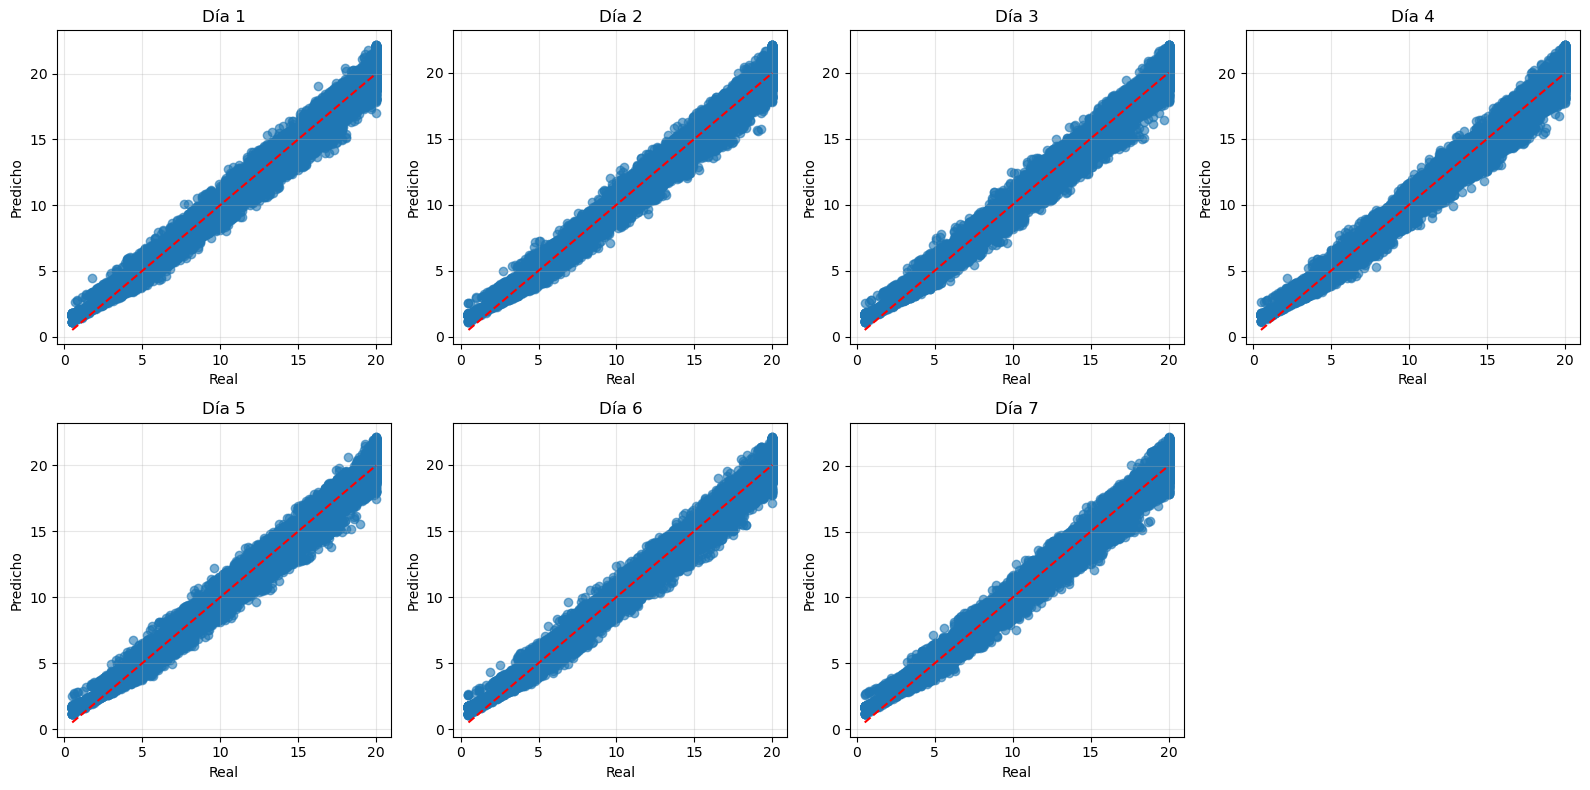

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, dia in enumerate(range(1, 8)):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh'])
    y = df_dia['Energy_Consumption_kWh']
    
    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste='truncar'
    )
    
    # Predicciones
    X_lista = X.values.tolist()
    y_pred = []
    for fila in X_lista:
        pred = float(intercepto)
        for i, nombre in enumerate(nombres):
            pred += float(coeficientes[i]) * fila[i]
        y_pred.append(pred)
    
    # Graficar
    axes[idx].scatter(y.tolist(), y_pred, alpha=0.6)
    axes[idx].plot([min(y), max(y)], [min(y), max(y)], 'r--')
    axes[idx].set_title(f'Día {dia}')
    axes[idx].set_xlabel('Real')
    axes[idx].set_ylabel('Predicho')
    axes[idx].grid(True, alpha=0.3)

# Ocultar subplot extra
axes[7].axis('off')

plt.tight_layout()
plt.show()


Día 1:
  y = -0.0472 + 0.9472*Household_Size + 0.0245*Avg_Temperature_C + -0.4845*Has_AC + 1.6518*Peak_Hours_Usage_kWh

Día 2:
  y = 0.0350 + 0.9428*Household_Size + 0.0191*Avg_Temperature_C + -0.4692*Has_AC + 1.6535*Peak_Hours_Usage_kWh

Día 3:
  y = 0.0370 + 0.9487*Household_Size + 0.0194*Avg_Temperature_C + -0.4734*Has_AC + 1.6480*Peak_Hours_Usage_kWh

Día 4:
  y = 0.0484 + 0.9483*Household_Size + 0.0189*Avg_Temperature_C + -0.4676*Has_AC + 1.6473*Peak_Hours_Usage_kWh

Día 5:
  y = 0.0306 + 0.9514*Household_Size + 0.0195*Avg_Temperature_C + -0.4496*Has_AC + 1.6454*Peak_Hours_Usage_kWh

Día 6:
  y = 0.0276 + 0.9501*Household_Size + 0.0202*Avg_Temperature_C + -0.4955*Has_AC + 1.6447*Peak_Hours_Usage_kWh

Día 7:
  y = 0.0671 + 0.9573*Household_Size + 0.0176*Avg_Temperature_C + -0.4472*Has_AC + 1.6391*Peak_Hours_Usage_kWh


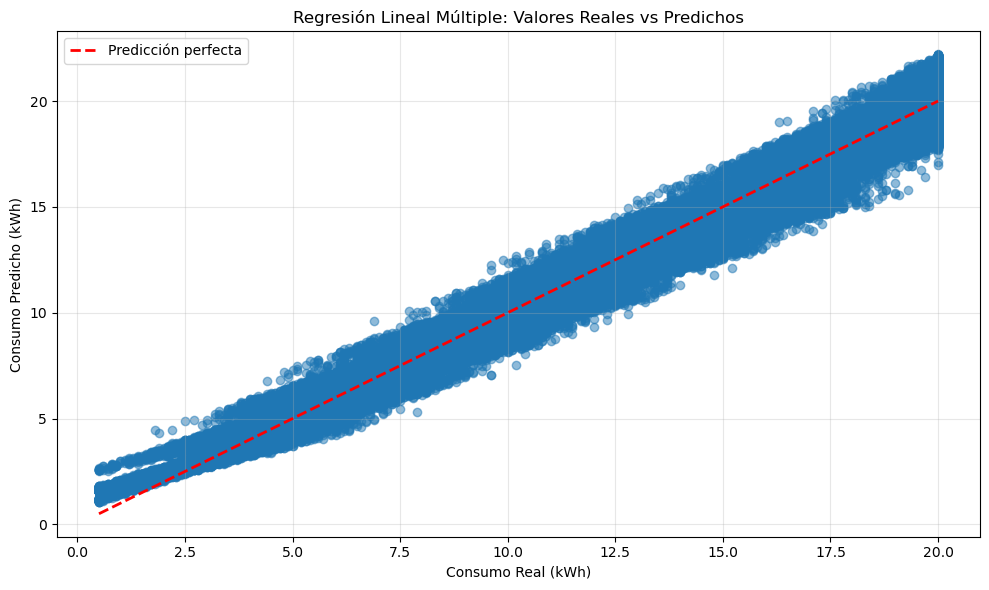

In [10]:


ecuaciones = {}
predicciones_totales = []
reales_totales = []

# Ajustar un modelo por cada día (1 a 7)
for dia in range(1, 8):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh'])
    y = df_dia['Energy_Consumption_kWh']
    
    # Usar tu función personalizada
    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste='truncar'
    )
    
    ecuaciones[dia] = {
        'intercepto': intercepto,
        'coeficientes': dict(zip(nombres, coeficientes))
    }
    
    # Calcular predicciones
    X_lista = X.values.tolist()
    y_pred = []
    for fila in X_lista:
        pred = float(intercepto)
        for i, nombre in enumerate(nombres):
            pred += float(coeficientes[i]) * fila[i]
        y_pred.append(pred)
    
    predicciones_totales.extend(y_pred)
    reales_totales.extend(y.tolist())

# Mostrar las ecuaciones
for dia, eq in ecuaciones.items():
    print(f"\nDía {dia}:")
    terminos = [f"{coef}*{var}" for var, coef in eq['coeficientes'].items()]
    print(f"  y = {eq['intercepto']} + " + " + ".join(terminos))

# GRÁFICA: Valores Reales vs Predichos
plt.figure(figsize=(10, 6))
plt.scatter(reales_totales, predicciones_totales, alpha=0.5)
plt.plot([min(reales_totales), max(reales_totales)], 
         [min(reales_totales), max(reales_totales)], 
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Consumo Real (kWh)')
plt.ylabel('Consumo Predicho (kWh)')
plt.title('Regresión Lineal Múltiple: Valores Reales vs Predichos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# MÉTODOS MATRICIALES - GAUSS-JORDAN Y GAUSS-SEIDEL
# ============================================================================

import numpy as np

class MetodosMatriciales:
    """Métodos para resolver ecuaciones de mínimos cuadrados"""
    
    def __init__(self, decimales=4):
        self.decimales = decimales
    
    def resolver_gauss_jordan(self, X, y, mostrar_pasos=False):
        """Resuelve usando Gauss-Jordan"""
        # Agregar columna de 1's
        n_muestras = X.shape[0]
        X_con_intercepto = np.column_stack([np.ones(n_muestras), X])
        
        # Ecuaciones normales: (X'X)β = X'y
        A = X_con_intercepto.T @ X_con_intercepto
        b = X_con_intercepto.T @ y
        
        if mostrar_pasos:
            print(f"\n{'='*70}")
            print("MÉTODO GAUSS-JORDAN")
            print(f"{'='*70}")
            print(f"\nMatriz A (X'X): {A.shape}")
            print(A)
            print(f"\nVector b (X'y):")
            print(b)
        
        beta = self._gauss_jordan(A.copy(), b.copy(), mostrar_pasos)
        return beta[0], beta[1:]  # intercepto, coeficientes
    
    def resolver_gauss_seidel(self, X, y, max_iter=1000, tolerancia=1e-6, mostrar_pasos=False):
        """Resuelve usando Gauss-Seidel"""
        n_muestras = X.shape[0]
        X_con_intercepto = np.column_stack([np.ones(n_muestras), X])
        
        A = X_con_intercepto.T @ X_con_intercepto
        b = X_con_intercepto.T @ y
        
        if mostrar_pasos:
            print(f"\n{'='*70}")
            print("MÉTODO GAUSS-SEIDEL")
            print(f"{'='*70}")
        
        beta, iters = self._gauss_seidel(A.copy(), b.copy(), max_iter, tolerancia, mostrar_pasos)
        return beta[0], beta[1:], iters
    
    def _gauss_jordan(self, A, b, mostrar=False):
        """Algoritmo Gauss-Jordan con pivoteo"""
        n = len(b)
        Ab = np.column_stack([A, b])
        
        if mostrar:
            print("\nMatriz aumentada [A|b]:")
            self._print_matriz(Ab)
        
        for i in range(n):
            # Pivoteo
            max_fila = i + np.argmax(np.abs(Ab[i:n, i]))
            if max_fila != i:
                Ab[[i, max_fila]] = Ab[[max_fila, i]]
                if mostrar:
                    print(f"\n▶ Intercambiar F{i+1} ↔ F{max_fila+1}")
                    self._print_matriz(Ab)
            
            if abs(Ab[i, i]) < 1e-10:
                raise ValueError(f"Sistema singular en fila {i+1}")
            
            # Normalizar
            pivote = Ab[i, i]
            Ab[i] = Ab[i] / pivote
            if mostrar:
                print(f"\n▶ F{i+1} = F{i+1} / {pivote:.4f}")
                self._print_matriz(Ab)
            
            # Eliminar
            for j in range(n):
                if j != i and Ab[j, i] != 0:
                    factor = Ab[j, i]
                    Ab[j] = Ab[j] - factor * Ab[i]
                    if mostrar:
                        print(f"\n▶ F{j+1} = F{j+1} - ({factor:.4f}) × F{i+1}")
                        self._print_matriz(Ab)
        
        x = Ab[:, -1]
        if mostrar:
            print(f"\n{'='*70}")
            print("✓ SOLUCIÓN:")
            for i, val in enumerate(x):
                print(f"  β{i} = {val:.{self.decimales}f}")
        
        return np.round(x, self.decimales)
    
    def _gauss_seidel(self, A, b, max_iter, tol, mostrar=False):
        """Algoritmo Gauss-Seidel"""
        n = len(b)
        x = np.zeros(n)
        x_prev = x.copy()
        
        if mostrar:
            print(f"\nVector inicial: x⁽⁰⁾ = {x}")
        
        for k in range(1, max_iter + 1):
            for i in range(n):
                suma = sum(A[i, j] * x[j] for j in range(n) if j != i)
                x[i] = (b[i] - suma) / A[i, i]
            
            error = np.linalg.norm(x - x_prev) / np.linalg.norm(x)
            
            if mostrar and (k <= 3 or k % 100 == 0 or error < tol):
                print(f"\nIter {k}: x = {x}, error = {error:.2e}")
            
            if error < tol:
                if mostrar:
                    print(f"\n Convergencia en {k} iteraciones")
                return np.round(x, self.decimales), k
            
            x_prev = x.copy()
        
        print(f"No convergió en {max_iter} iter")
        return np.round(x, self.decimales), max_iter
    

In [71]:
variables = list(next(iter(ecuaciones.values()))['coeficientes'].keys())

A = []
b = []

for dia, eq in ecuaciones.items():
    fila = [eq['coeficientes'][var] for var in variables]
    A.append(fila)
    b.append(eq['intercepto'])

A = np.array(A, dtype=float)
b = np.array(b, dtype=float)

print("Matriz A:")
print(A)

print("\nVector b:")
print(b)


Matriz A:
[[ 0.9472  0.0246 -0.4846  1.6519]
 [ 0.9428  0.0192 -0.4692  1.6536]
 [ 0.9488  0.0194 -0.4734  1.648 ]
 [ 0.9484  0.019  -0.4677  1.6473]
 [ 0.9514  0.0196 -0.4496  1.6454]
 [ 0.9502  0.0203 -0.4956  1.6448]
 [ 0.9574  0.0176 -0.4472  1.6391]]

Vector b:
[-0.0472  0.0351  0.037   0.0485  0.0306  0.0276  0.0672]


In [67]:
metodos = MetodosMatriciales(decimales=4)

A = np.array(A, dtype=float)  # 7x4
b = np.array(b, dtype=float)  # 7

# Construir sistema normal
A2 = A.T @ A
b2 = A.T @ b

print("Matriz A^T A:")
print(A2)

print("\nVector A^T b:")
print(b2)

# Resolver con TU Gauss-Jordan
solucion = metodos._gauss_jordan(A2.copy(), b2.copy(), mostrar=True)

variables = ['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh']

print("\nSolución final (método matricial):")
for var, val in zip(variables, solucion):
    print(f"{var} = {val}")


Matriz A^T A:
[[ 6.31040044e+00  1.32615940e-01 -3.12092132e+00  1.09472123e+01]
 [ 1.32615940e-01  2.81717000e-03 -6.57436200e-02  2.30143200e-01]
 [-3.12092132e+00 -6.57436200e-02  1.54558401e+00 -5.41492551e+00]
 [ 1.09472123e+01  2.30143200e-01 -5.41492551e+00  1.89920249e+01]]

Vector A^T b:
[ 0.18916308  0.00349486 -0.09128321  0.32683497]

Matriz aumentada [A|b]:
    6.3104   0.1326  -3.1209  10.9472 |   0.1892
    0.1326   0.0028  -0.0657   0.2301 |   0.0035
   -3.1209  -0.0657   1.5456  -5.4149 |  -0.0913
   10.9472   0.2301  -5.4149  18.9920 |   0.3268

▶ Intercambiar F1 ↔ F4
   10.9472   0.2301  -5.4149  18.9920 |   0.3268
    0.1326   0.0028  -0.0657   0.2301 |   0.0035
   -3.1209  -0.0657   1.5456  -5.4149 |  -0.0913
    6.3104   0.1326  -3.1209  10.9472 |   0.1892

▶ F1 = F1 / 10.9472
    1.0000   0.0210  -0.4946   1.7349 |   0.0299
    0.1326   0.0028  -0.0657   0.2301 |   0.0035
   -3.1209  -0.0657   1.5456  -5.4149 |  -0.0913
    6.3104   0.1326  -3.1209  10.9472 |   0

In [68]:
A2 = A.T @ A
b2 = A.T @ b

sol, iters = metodos._gauss_seidel(A2.copy(), b2.copy(), max_iter=1000, tol=1e-6, mostrar=True)

print("\nSolución por Gauss-Seidel:")
for var, val in zip(variables, sol):
    print(f"{var} = {val}")

print("Iteraciones:", iters)


Vector inicial: x⁽⁰⁾ = [0. 0. 0. 0.]

Iter 1: x = [ 0.0299764  -0.17055708 -0.00578569  0.00034754], error = 1.00e+00

Iter 2: x = [ 0.03009641 -0.33961731 -0.01151698  0.00069293], error = 4.96e-01

Iter 3: x = [ 0.03021559 -0.50719364 -0.01719433  0.0010362 ], error = 3.30e-01

Iter 100: x = [  0.03873234 -11.36679816  -0.37224111   0.02649308], error = 6.23e-03

Iter 200: x = [  0.04377358 -16.00154039  -0.50180527   0.04280975], error = 1.78e-03

Iter 300: x = [  0.04716165 -17.82320603  -0.53190493   0.05434968], error = 6.03e-04

Iter 400: x = [  0.04981595 -18.47526293  -0.52242661   0.06342368], error = 1.86e-04

Iter 500: x = [  0.05212559 -18.6464001   -0.49830935   0.07104241], error = 2.91e-05

Iter 600: x = [  0.05425684 -18.62473796  -0.4698441    0.07766733], error = 4.07e-05

Iter 700: x = [  0.05628221 -18.53038373  -0.44119047   0.08352611], error = 6.17e-05

Iter 800: x = [  0.05823464 -18.41301183  -0.41394916   0.08874534], error = 6.72e-05

Iter 900: x = [  0.060

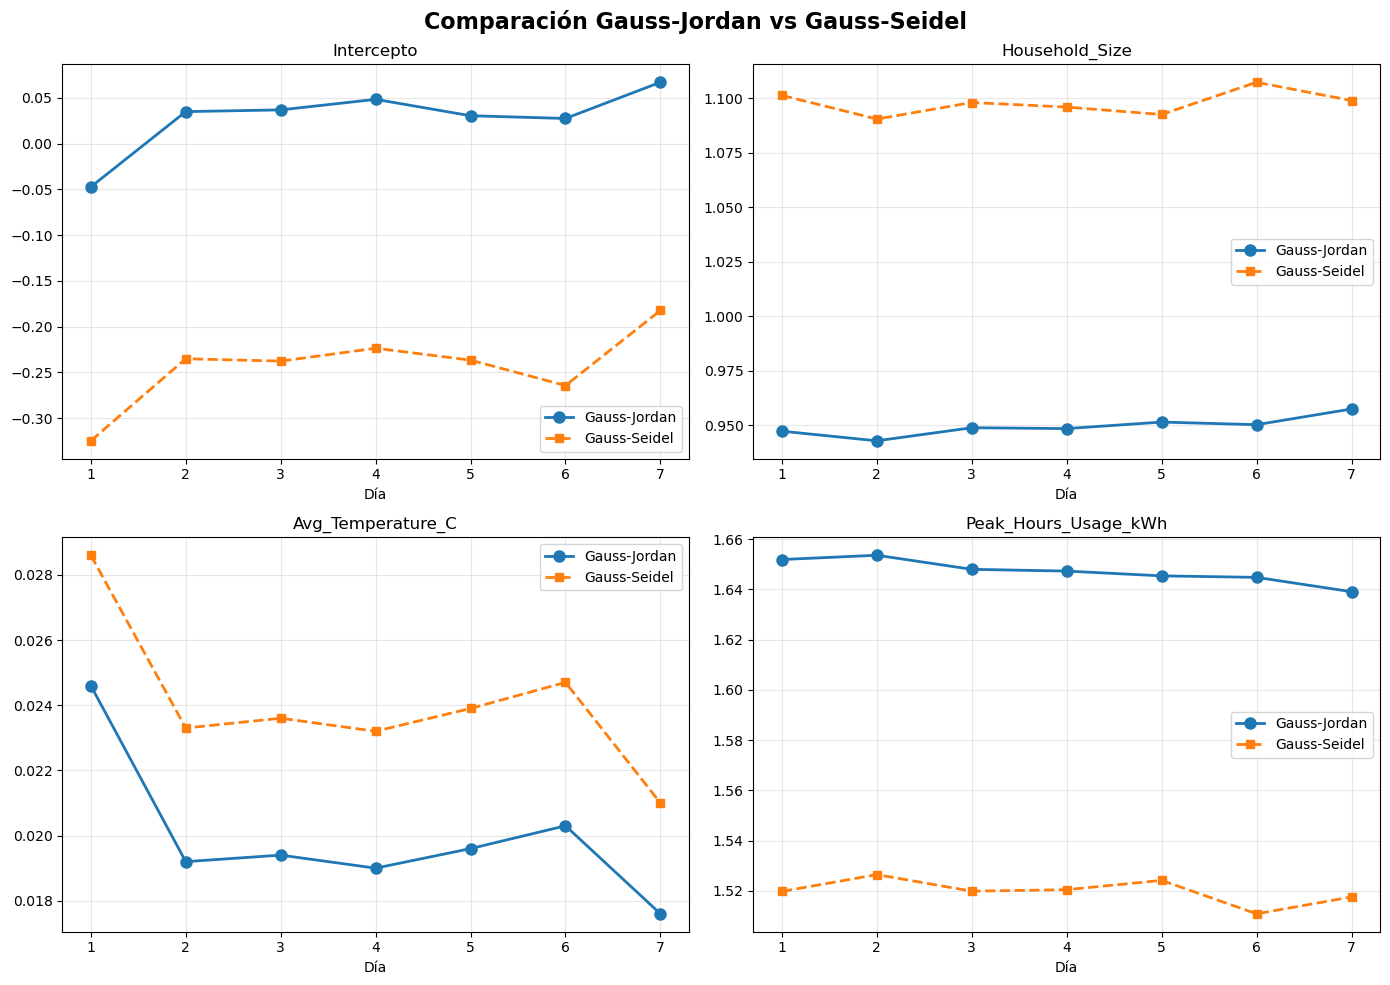

In [57]:
# Gráfica de comparación
import matplotlib.pyplot as plt

dias = list(ecuaciones.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación Gauss-Jordan vs Gauss-Seidel', fontsize=16, fontweight='bold')

# Intercepto
int_gj = [eq['intercepto'] for eq in ecuaciones.values()]
int_gs = [eq['intercepto'] for eq in ecuaciones_gs.values()]
axes[0,0].plot(dias, int_gj, 'o-', label='Gauss-Jordan', linewidth=2, markersize=8)
axes[0,0].plot(dias, int_gs, 's--', label='Gauss-Seidel', linewidth=2, markersize=6)
axes[0,0].set_title('Intercepto')
axes[0,0].set_xlabel('Día')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Coeficientes (ajusta los nombres según tus variables)
nombres_vars = ['Household_Size', 'Avg_Temperature_C', 'Peak_Hours_Usage_kWh']
for idx, var in enumerate(nombres_vars):
    row = (idx + 1) // 2
    col = (idx + 1) % 2
    
    coef_gj = [eq['coeficientes'][var] for eq in ecuaciones.values()]
    coef_gs = [eq['coeficientes'][var] for eq in ecuaciones_gs.values()]
    
    axes[row,col].plot(dias, coef_gj, 'o-', label='Gauss-Jordan', linewidth=2, markersize=8)
    axes[row,col].plot(dias, coef_gs, 's--', label='Gauss-Seidel', linewidth=2, markersize=6)
    axes[row,col].set_title(var)
    axes[row,col].set_xlabel('Día')
    axes[row,col].legend()
    axes[row,col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()